# DeepLabCut skeleton on black canvas (5 fps)

Picks a **random** training-suitable snippet from the manifest that has both a **snippet MP4** and a matching **DeepLabCut `.h5`** (same resolution as `model_training_v2/config_stgcn_dlc.yaml`).

Writes an MP4 at **5 frames per second** with a **black background** and only the **39-keypoint SuperAnimal quadruped** skeleton (edges + joints), scaled to fit the video frame size.

**Dependencies:** `opencv-python`, `numpy`, `pandas`, `pyyaml`, `pillow`, `h5py` (or `tables` for HDF5 via pandas), and **IPython**.

After rendering, the code cell writes **GIF previews** (OpenCV MP4s often use the `mp4v` codec, which the notebook HTML5 video player cannot decode in VS Code / Cursor). MP4s are still saved next to the GIFs for VLC / QuickTime.

Run all cells from the repo (or any subfolder); the code cell locates the repository root.

If the inline GIF still does not render, run the **Optional Gradio** cells at the end (`pip install gradio`).
**Graph:** edges come from `model_training_v2/quadruped_skeleton_spec.py` (same ST-GCN adjacency as training) plus one cosmetic mouth edge. DLC likelihoods are low on many joints — the notebook uses **lenient** cuts for drawing only.


/var/folders/vb/9lm3mj5n1_573j4kn1bw4fnc0000gn/T/ipykernel_28893/2795609680.py:203: UserWarning: Multiple HDF5 for '7234746956168367402_snip_0' (2 with suffix '_superanimal_quadruped_hrnet_w32_fasterrcnn_mobilenet_v3_large_fpn.h5'); picking: '7234746956168367402_snip_0_superanimal_quadruped_snapshot-hrnet_w32-004_snapshot-fasterrcnn_mobilenet_v3_large_fpn-004_labeled_after_adapt_superanimal_quadruped_hrnet_w32_fasterrcnn_mobilenet_v3_large_fpn.h5' (prefers no _labeled_, avoids labeled_before_adapt dup, then shortest). Remove extras or set a longer data.dlc_h5_suffix to be strict.
  h5 = resolve_dlc_h5_path(dlc_dir, sid, suffix)


snippet_id: 4_As16XG0-Y_snip_3
video: dataset/snippets_v2/4_As16XG0-Y_snip_3.mp4
dlc h5: dataset/deeplabcut_really_labeled/4_As16XG0-Y_snip_3_superanimal_quadruped_hrnet_w32_fasterrcnn_mobilenet_v3_large_fpn.h5
audio_label_10: MotherCall
pose shape (T, J, 3): (16, 39, 3)
Wrote: model_training_v2/runs/notebook_outputs/dlc_skeleton_black_4_As16XG0-Y_snip_3.mp4



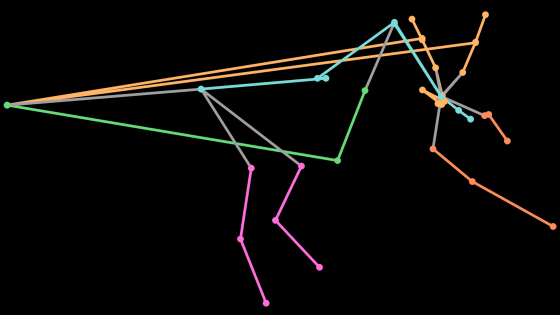

face,
neck_spine,
front_legs,
back_legs,
belly,
Between regions (edges),



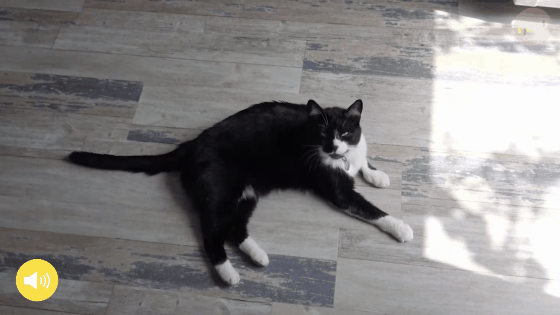

GIF skeleton: /Users/viktorzozula/Documents/Cats-in-Pain-Bachelors/model_training_v2/runs/notebook_outputs/dlc_skeleton_black_4_As16XG0-Y_snip_3_preview_skeleton.gif
GIF original: /Users/viktorzozula/Documents/Cats-in-Pain-Bachelors/model_training_v2/runs/notebook_outputs/dlc_skeleton_black_4_As16XG0-Y_snip_3_preview_orig.gif


In [118]:
from __future__ import annotations

import json
import random
import sys
from pathlib import Path

import cv2
import numpy as np
import yaml


import pandas as pd
from scipy.ndimage import median_filter
from scipy.signal import savgol_filter


def find_repo_root() -> Path:
    p = Path.cwd().resolve()
    for _ in range(16):
        if (p / "model_training_v2" / "config_stgcn_dlc.yaml").is_file():
            return p
        p = p.parent
    raise FileNotFoundError(
        "Could not find repo root (need model_training_v2/config_stgcn_dlc.yaml). "
        "Open the notebook from the Cats-in-Pain-Bachelors tree or cd there first."
    )


REPO = find_repo_root()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from model_training_v2.data_loading import resolve_dlc_h5_path
from model_training_v2.deeplabcut_pose_io import load_dlc_h5_tensor
from model_training_v2.quadruped_skeleton_spec import (
    INTER_REGION_EDGE_BGR,
    JOINT_REGION,
    REGION_COLOR_BGR,
    SKELETON_EDGES as _STGCN_EDGES,
    VIZ_SUPPLEMENT_EDGES,
)

# ST-GCN training graph + small set of cosmetic edges (e.g. mouth corners) for clearer demos.
_EDGES_SEQ: list[tuple[int, int]] = list(_STGCN_EDGES) + list(VIZ_SUPPLEMENT_EDGES)
EDGES_DRAW: list[tuple[int, int]] = list(dict.fromkeys(_EDGES_SEQ))

def _edge_bgr(a: int, b: int) -> tuple[int, int, int]:
    ra, rb = JOINT_REGION[a], JOINT_REGION[b]
    if ra == rb:
        return REGION_COLOR_BGR[ra]
    return INTER_REGION_EDGE_BGR


def _joint_bgr(j: int) -> tuple[int, int, int]:
    return REGION_COLOR_BGR[JOINT_REGION[j]]


def _dim_bgr(col: tuple[int, int, int], factor: float) -> tuple[int, int, int]:
    return tuple(int(max(0, min(255, c * factor))) for c in col)


def stabilize_keypoints(
    pose_txj3: np.ndarray,
    stable_lh_threshold: float = 0.5,
    window: int = 5,
    polyorder: int = 2,
) -> np.ndarray:
    """Hold last high-confidence pose, then Savitzky-Golay on x/y.

    Frames with likelihood below the threshold get x/y replaced by the most recent *stable*
    observation on that joint. DLC likelihood is in ``[0, 1]``; pass ``0.5`` or ``50`` (treated
    as 50% on a 0--100 scale when ``> 1``) for a 50% confidence cutoff. ``bfill`` fills any
    leading low-confidence stretch from the first stable frame.

    Likelihoods are left unchanged on return so downstream drawing still reflects raw DLC.
    """
    smoothed = pose_txj3.astype(np.float64, copy=True)
    t_max, j_max, _ = smoothed.shape
    lh_orig = pose_txj3[:, :, 2].astype(np.float32, copy=False)

    th = float(stable_lh_threshold)
    if th > 1.0:
        th = th / 100.0
    th = float(max(0.0, min(1.0, th)))

    win = window
    if win % 2 == 0:
        win += 1
    win = min(win, t_max if t_max % 2 != 0 else t_max - 1)
    can_savgol = win >= 3 and win > polyorder

    for j in range(j_max):
        x = smoothed[:, j, 0].astype(np.float64, copy=False)
        y = smoothed[:, j, 1].astype(np.float64, copy=False)
        lh = smoothed[:, j, 2]

        stable = (lh >= th) & np.isfinite(x) & np.isfinite(y)
        xw = np.where(stable, x, np.nan)
        yw = np.where(stable, y, np.nan)
        xs = pd.Series(xw).ffill().bfill().to_numpy()
        ys = pd.Series(yw).ffill().bfill().to_numpy()

        if not (np.all(np.isfinite(xs)) and np.all(np.isfinite(ys))):
            continue

        if can_savgol:
            xs = savgol_filter(xs, window_length=win, polyorder=polyorder)
            ys = savgol_filter(ys, window_length=win, polyorder=polyorder)

        smoothed[:, j, 0] = xs
        smoothed[:, j, 1] = ys

    out = smoothed.astype(np.float32, copy=False)
    out[:, :, 2] = lh_orig
    return out


def remove_outlier_jumps(
    pose_txj3: np.ndarray,
    max_jump_px: float = 40.0,
    lh_threshold: float = 0.3,
) -> np.ndarray:
    """If a joint jumps farther than ``max_jump_px`` in one frame and LH is low, snap to previous xy."""
    out = pose_txj3.copy()
    t_max, j_max, _ = out.shape
    for j in range(j_max):
        for t in range(1, t_max):
            lh = float(out[t, j, 2])
            dx = float(out[t, j, 0]) - float(out[t - 1, j, 0])
            dy = float(out[t, j, 1]) - float(out[t - 1, j, 1])
            dist = float(np.hypot(dx, dy))
            if dist > max_jump_px and lh < lh_threshold:
                out[t, j, 0] = out[t - 1, j, 0]
                out[t, j, 1] = out[t - 1, j, 1]
    return out


def smooth_pose_median(pose_txj3: np.ndarray, kernel: int = 5) -> np.ndarray:
    """Per-joint temporal median on x and y (kills single-frame spikes)."""
    out = pose_txj3.copy()
    t_max, j_max, _ = out.shape
    k = kernel
    if k % 2 == 0:
        k += 1
    k = min(k, t_max if t_max % 2 == 1 else t_max - 1)
    if k < 1:
        return out
    for j in range(j_max):
        out[:, j, 0] = median_filter(pose_txj3[:, j, 0], size=k)
        out[:, j, 1] = median_filter(pose_txj3[:, j, 1], size=k)
    return out


# DLC likelihood is in [0,1]. Training uses strict gates; for *drawing*, use low cuts so limbs stay visible.
VIZ_LH_JOINT = 0.02
VIZ_LH_EDGE_STRONG = 0.035
VIZ_LH_EDGE_WEAK = 0.012
VIZ_BBOX_LH = 0.008


def resolve_video_path(repo: Path, rel: str | None) -> Path | None:
    if not rel or not str(rel).strip():
        return None
    p = Path(rel)
    if p.is_file():
        return p.resolve()
    cand = repo / rel
    if cand.is_file():
        return cand.resolve()
    return None


def pick_random_snippet_with_dlc(
    repo: Path,
    cfg: dict,
    *,
    rng: random.Random | None = None,
) -> tuple[dict, Path, Path]:
    """Uniform random qualifying row in one manifest pass (reservoir sampling)."""
    rng = rng or random.Random()
    manifest = repo / str(cfg["data"]["manifest"])
    dlc_dir = Path(cfg["data"]["dlc_dir"])
    if not dlc_dir.is_absolute():
        dlc_dir = repo / dlc_dir
    suffix = str(cfg["data"].get("dlc_h5_suffix", "")).strip()

    chosen: tuple[dict, Path, Path] | None = None
    k = 0
    scanned = 0
    with open(manifest, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            scanned += 1
            row = json.loads(line)
            if row.get("suitable_for_training") is not True:
                continue
            sid = row.get("snippet_id")
            if not isinstance(sid, str) or not sid:
                continue
            h5 = resolve_dlc_h5_path(dlc_dir, sid, suffix)
            if h5 is None or not h5.is_file():
                continue
            vpath = resolve_video_path(repo, row.get("video_path"))
            if vpath is None:
                continue
            k += 1
            if k == 1 or rng.randint(1, k) == 1:
                chosen = (row, h5, vpath)

    if chosen is None:
        raise RuntimeError(
            "No suitable rows with both DLC .h5 and video_path found "
            f"(manifest={manifest}, scanned_lines={scanned})."
        )
    return chosen


def bbox_from_pose(pose_txj3: np.ndarray, lh_min: float) -> tuple[float, float, float, float] | None:
    """Axis-aligned bbox (xmin, xmax, ymin, ymax) over time for joints above ``lh_min``."""
    lh = pose_txj3[..., 2]
    xy = pose_txj3[..., :2]
    m = lh >= lh_min
    if not np.any(m):
        return None
    xs = xy[..., 0][m]
    ys = xy[..., 1][m]
    return float(xs.min()), float(xs.max()), float(ys.min()), float(ys.max())


def map_xy_to_canvas(
    x: float,
    y: float,
    bbox: tuple[float, float, float, float],
    out_w: int,
    out_h: int,
    margin: int = 24,
) -> tuple[int, int]:
    xmin, xmax, ymin, ymax = bbox
    bw = max(xmax - xmin, 1e-6)
    bh = max(ymax - ymin, 1e-6)
    inner_w = max(out_w - 2 * margin, 1)
    inner_h = max(out_h - 2 * margin, 1)
    scale = min(inner_w / bw, inner_h / bh)
    cx = (xmin + xmax) / 2.0
    cy = (ymin + ymax) / 2.0
    ox = out_w / 2.0
    oy = out_h / 2.0
    u = (x - cx) * scale + ox
    v = (y - cy) * scale + oy
    return int(round(u)), int(round(v))


def render_skeleton_video(
    pose_txj3: np.ndarray,
    out_path: Path,
    *,
    frame_size_wh: tuple[int, int],
    fps: float = 5.0,
    lh_edge_strong: float = VIZ_LH_EDGE_STRONG,
    lh_edge_weak: float = VIZ_LH_EDGE_WEAK,
    lh_joint: float = VIZ_LH_JOINT,
) -> None:
    out_w, out_h = frame_size_wh
    T, J, _ = pose_txj3.shape
    bbox = bbox_from_pose(pose_txj3, VIZ_BBOX_LH)
    if bbox is None:
        bbox = (0.0, float(out_w), 0.0, float(out_h))

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(out_path), fourcc, float(fps), (out_w, out_h))
    if not writer.isOpened():
        raise OSError(f"VideoWriter failed to open: {out_path}")

    line_th = max(2, min(out_w, out_h) // 140)
    rad = max(4, min(out_w, out_h) // 95)
    for t in range(T):
        canvas = np.zeros((out_h, out_w, 3), dtype=np.uint8)
        pts: list[tuple[int, int] | None] = [None] * J
        for j in range(J):
            x, y, lh = float(pose_txj3[t, j, 0]), float(pose_txj3[t, j, 1]), float(pose_txj3[t, j, 2])
            if lh >= lh_joint and np.isfinite(x) and np.isfinite(y):
                pts[j] = map_xy_to_canvas(x, y, bbox, out_w, out_h)
        for a, b in EDGES_DRAW:
            pa, pb = pts[a], pts[b]
            if pa is None or pb is None:
                continue
            la, lb = float(pose_txj3[t, a, 2]), float(pose_txj3[t, b, 2])
            if la < lh_edge_weak or lb < lh_edge_weak:
                continue
            base = _edge_bgr(a, b)
            if min(la, lb) >= lh_edge_strong:
                col, th = base, line_th
            elif 0.5 * (la + lb) >= lh_edge_strong:
                col, th = _dim_bgr(base, 0.88), max(1, line_th - 1)
            elif min(la, lb) >= lh_edge_weak:
                col, th = _dim_bgr(base, 0.58), max(1, line_th - 1)
            else:
                continue
            cv2.line(canvas, pa, pb, col, th, lineType=cv2.LINE_AA)
        for j in range(J):
            if pts[j] is None:
                continue
            cv2.circle(canvas, pts[j], rad, _joint_bgr(j), -1, lineType=cv2.LINE_AA)
        writer.write(canvas)
    writer.release()


def skeleton_frames_bgr_from_pose(
    pose_txj3: np.ndarray,
    frame_size_wh: tuple[int, int],
    lh_edge_strong: float = VIZ_LH_EDGE_STRONG,
    lh_edge_weak: float = VIZ_LH_EDGE_WEAK,
    lh_joint: float = VIZ_LH_JOINT,
) -> list[np.ndarray]:
    """Same pixels as ``render_skeleton_video`` without reading the MP4 back.

    OpenCV ``mp4v`` output is often not decodable by ``cv2.VideoCapture`` in the same
    environment, so previews must be built from the pose tensor.
    """
    out_w, out_h = frame_size_wh
    t_max, j_max, _ = pose_txj3.shape
    bbox = bbox_from_pose(pose_txj3, VIZ_BBOX_LH)
    if bbox is None:
        bbox = (0.0, float(out_w), 0.0, float(out_h))
    line_th = max(2, min(out_w, out_h) // 140)
    rad = max(4, min(out_w, out_h) // 95)
    frames: list[np.ndarray] = []
    for t in range(t_max):
        canvas = np.zeros((out_h, out_w, 3), dtype=np.uint8)
        pts: list[tuple[int, int] | None] = [None] * j_max
        for j in range(j_max):
            x, y, lh = float(pose_txj3[t, j, 0]), float(pose_txj3[t, j, 1]), float(pose_txj3[t, j, 2])
            if lh >= lh_joint and np.isfinite(x) and np.isfinite(y):
                pts[j] = map_xy_to_canvas(x, y, bbox, out_w, out_h)
        for a, b in EDGES_DRAW:
            pa, pb = pts[a], pts[b]
            if pa is None or pb is None:
                continue
            la, lb = float(pose_txj3[t, a, 2]), float(pose_txj3[t, b, 2])
            if la < lh_edge_weak or lb < lh_edge_weak:
                continue
            base = _edge_bgr(a, b)
            if min(la, lb) >= lh_edge_strong:
                col, th = base, line_th
            elif 0.5 * (la + lb) >= lh_edge_strong:
                col, th = _dim_bgr(base, 0.88), max(1, line_th - 1)
            elif min(la, lb) >= lh_edge_weak:
                col, th = _dim_bgr(base, 0.58), max(1, line_th - 1)
            else:
                continue
            cv2.line(canvas, pa, pb, col, th, lineType=cv2.LINE_AA)
        for j in range(j_max):
            if pts[j] is None:
                continue
            cv2.circle(canvas, pts[j], rad, _joint_bgr(j), -1, lineType=cv2.LINE_AA)
        frames.append(canvas)
    return frames


# --- run ---
CFG_PATH = REPO / "model_training_v2" / "config_stgcn_dlc.yaml"
with open(CFG_PATH, encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

SEED = None  # set an int for reproducible random snippet
rng = random.Random(SEED)

row, h5_path, video_path = pick_random_snippet_with_dlc(REPO, cfg, rng=rng)
sid = str(row["snippet_id"])
print("snippet_id:", sid)
print("video:", video_path.relative_to(REPO))
print("dlc h5:", h5_path.relative_to(REPO))
print("audio_label_10:", row.get("audio_label_10"))

cap = cv2.VideoCapture(str(video_path))
if not cap.isOpened():
    raise OSError(f"Cannot open video: {video_path}")
ok, first = cap.read()
cap.release()
if not ok or first is None:
    raise OSError("No frames in snippet video")
H, W = first.shape[:2]

pose, meta = load_dlc_h5_tensor(h5_path)
if meta.get("error"):
    raise RuntimeError(meta)
T = int(pose.shape[0])
print("pose shape (T, J, 3):", pose.shape)

# Temporal stabilization (order matters: outlier snap → hold-low-LH + SavGol → median).
# max_jump_px: in normalized coords. If fast motion looks frozen, try 0.12–0.15; if ghosts remain, try 0.05.
#   Calibrate: set PRINT_SMOOTHING_JUMP_STATS True, read 95th/99th pct, pick max_jump_px between them.
# window / polyorder: 13 + 1 is strong smooth at 5 fps; if the skeleton lags on sit→stand, try window=9, polyorder=2.
# Kalman (filterpy): optional step 4 — coasts on velocity for low-LH frames instead of hold-ffill.
PRINT_SMOOTHING_JUMP_STATS = False
if PRINT_SMOOTHING_JUMP_STATS and pose.shape[0] >= 2:
    _d = np.sqrt(np.sum(np.diff(pose[:, :, :2], axis=0) ** 2, axis=-1))
    print("95th pct frame-to-frame jump (per joint):", float(np.percentile(_d, 95)))
    print("99th pct frame-to-frame jump (per joint):", float(np.percentile(_d, 99)))

pose = remove_outlier_jumps(pose, max_jump_px=0.08, lh_threshold=0.35)
pose = stabilize_keypoints(pose, stable_lh_threshold=0.35, window=13, polyorder=1)
pose = smooth_pose_median(pose, kernel=5)

OUT_DIR = REPO / "model_training_v2" / "runs" / "notebook_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
out_mp4 = OUT_DIR / f"dlc_skeleton_black_{sid}.mp4"

OUTPUT_FPS = 5.0
render_skeleton_video(
    pose.astype(np.float32, copy=False),
    out_mp4,
    frame_size_wh=(W, H),
    fps=OUTPUT_FPS,
)
print("Wrote:", out_mp4.relative_to(REPO))


def _read_video_frames_bgr(path: Path, max_frames: int | None = None) -> list[np.ndarray]:
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise OSError(f"Cannot open {path}")
    frames: list[np.ndarray] = []
    while True:
        ok, fr = cap.read()
        if not ok or fr is None:
            break
        frames.append(fr)
        if max_frames is not None and len(frames) >= max_frames:
            break
    cap.release()
    return frames


def _frames_to_gif_bgr(frames_bgr: list[np.ndarray], out_gif: Path, *, fps: float, max_w: int = 560) -> None:
    from PIL import Image

    if not frames_bgr:
        raise ValueError("no frames for GIF")
    ims: list[Image.Image] = []
    for fr in frames_bgr:
        rgb = cv2.cvtColor(fr, cv2.COLOR_BGR2RGB)
        h, w = rgb.shape[:2]
        if w > max_w:
            nh = int(round(h * (max_w / w)))
            rgb = cv2.resize(rgb, (max_w, nh), interpolation=cv2.INTER_AREA)
        ims.append(Image.fromarray(rgb))
    duration_ms = int(round(1000.0 / max(fps, 1e-3)))
    out_gif.parent.mkdir(parents=True, exist_ok=True)
    ims[0].save(
        out_gif,
        save_all=True,
        append_images=ims[1:],
        duration=duration_ms,
        loop=0,
        optimize=False,
    )


import base64

# GIF from pose (not from MP4): same OpenCV build often cannot *decode* mp4v it wrote.
from IPython.display import HTML, display

sk_frames = skeleton_frames_bgr_from_pose(pose.astype(np.float32, copy=False), (W, H))
if not sk_frames:
    raise RuntimeError("No skeleton frames from pose (unexpected).")

orig_frames = _read_video_frames_bgr(video_path)
T_prev = len(sk_frames)
if orig_frames and len(orig_frames) != T_prev:
    idx = np.linspace(0, len(orig_frames) - 1, T_prev).astype(int)
    orig_frames = [orig_frames[i] for i in idx]

gif_sk = out_mp4.with_name(out_mp4.stem + "_preview_skeleton.gif")
_frames_to_gif_bgr(sk_frames, gif_sk, fps=float(OUTPUT_FPS))


def _display_gif_file(path: Path, title: str) -> None:
    path = path.resolve()
    if not path.is_file():
        display(HTML(f"<p style='color:red'>Missing GIF: <code>{path}</code></p>"))
        return
    b64 = base64.standard_b64encode(path.read_bytes()).decode("ascii")
    display(HTML(f"<h4>{title}</h4>"))
    display(
        HTML(
            f'<img src="data:image/gif;base64,{b64}" '
            'style="max-width:min(720px,100%);height:auto;border:1px solid #333" '
            f'alt="{title}" />'
        )
    )


_display_gif_file(gif_sk, "DLC skeleton on black canvas (GIF preview, 5 fps)")
_legend_rows = "".join(
    f"<tr><td style='padding:4px 8px'>{k}</td>"
    f"<td style='padding:4px;min-width:48px;background:rgb({c[2]},{c[1]},{c[0]})'>&nbsp;</td></tr>"
    for k, c in REGION_COLOR_BGR.items()
)
_ir = INTER_REGION_EDGE_BGR
_legend_rows += (
    f"<tr><td style='padding:4px 8px'><em>Between regions (edges)</em></td>"
    f"<td style='padding:4px;min-width:48px;background:rgb({_ir[2]},{_ir[1]},{_ir[0]})'>&nbsp;</td></tr>"
)
display(
    HTML(
        "<details><summary>Body-region color key</summary>"
        "<table style='border-collapse:collapse;margin:0.5em 0;font-size:0.95em'>"
        + _legend_rows
        + "</table></details>"
    )
)

if orig_frames:
    gif_orig = out_mp4.with_name(out_mp4.stem + "_preview_orig.gif")
    _frames_to_gif_bgr(orig_frames, gif_orig, fps=float(OUTPUT_FPS))
    _display_gif_file(gif_orig, "Original snippet (GIF preview, time-aligned)")
else:
    display(HTML("<p><em>Original video had no frames; skeleton preview only.</em></p>"))

print("GIF skeleton:", gif_sk.resolve())
if orig_frames:
    print("GIF original:", gif_orig.resolve())

display(
    HTML(
        "<p style='opacity:0.85'>MP4s stay on disk. Previews use embedded GIF (base64) so they show in "
        "VS Code / Cursor; skeleton GIF is rendered from the pose tensor, not by re-reading the MP4.</p>"
    )
)

### Optional: Gradio viewer

If the GIF still does not show in the notebook output, **run the next cell** after the main pipeline.

Requires: `pip install gradio`

It opens a small Gradio UI (inline iframe in Jupyter, or a browser tab in some environments) with the **same GIF files** the pipeline wrote to disk.

If Gradio says the **port is in use**, restart the notebook kernel and run the main cell, then this cell, **once**.


In [119]:
# Run right after the main cell (needs gif_sk, out_mp4, and optionally gif_orig).

try:
    import gradio as gr
except ImportError:
    print("Install Gradio: pip install gradio")
else:
    from pathlib import Path

    sk_path = Path(gif_sk).resolve()
    if not sk_path.is_file():
        raise FileNotFoundError(f"Missing skeleton GIF: {sk_path}")

    try:
        orig_path = Path(gif_orig).resolve()
        has_orig = orig_path.is_file()
    except NameError:
        has_orig = False
        orig_path = None

    mp4_path = Path(out_mp4).resolve()

    with gr.Blocks(title="DLC skeleton preview") as demo:
        gr.Markdown(
            "### Snippet vs skeleton\n"
            "GIF previews load from disk — useful when the notebook HTML output is stripped or blocked."
        )
        with gr.Row():
            if has_orig:
                gr.Image(
                    label="Original snippet (GIF)",
                    value=str(orig_path),
                    interactive=False
                )
            gr.Image(
                label="Skeleton on black (GIF)",
                value=str(sk_path),
                interactive=False
            )
        gr.Markdown(f"**Skeleton MP4 (open in VLC / QuickTime if needed):** `{mp4_path}`")

    demo.launch(
        inline=True,
        inbrowser=False,
        quiet=True,
        show_api=False,
        height=780,
        server_name="127.0.0.1",
    )


/var/folders/vb/9lm3mj5n1_573j4kn1bw4fnc0000gn/T/ipykernel_28893/2517504594.py:42: DeprecationWarning: The 'show_api' parameter in launch() will be removed in Gradio 6.0. You will need to use the 'footer_links' parameter instead. To replicate show_api=False, In Gradio 6.0, use footer_links=['gradio', 'settings'].
  demo.launch(
